# Handwritten digits revisited

This notebook reproduces the offline numerical summary for the MNIST
application. Each image is treated as a probability measure on the pixel grid.

The archived file contains complete-pair estimates for ten digit classes. It
also contains regular standard errors and first-projection variances.

In [1]:
from pathlib import Path
import sys

candidate = Path.cwd().resolve()
if (candidate / "src").is_dir():
    PUBLIC_ROOT = candidate
elif (candidate.parent / "src").is_dir():
    PUBLIC_ROOT = candidate.parent
else:
    raise RuntimeError("Start Jupyter in public or public/notebooks.")

sys.path.insert(0, str(PUBLIC_ROOT / "src"))
DATA_DIR = PUBLIC_ROOT / "data"
print(f"Public package: {PUBLIC_ROOT.name}")

Public package: public


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

## Class-specific uncertainty

Metric variance measures average squared transport dispersion within each
class. Larger values indicate that a digit class contains more varied shapes
under the chosen pixel-grid geometry.

In [3]:
mnist = pd.read_csv(DATA_DIR / "mnist_precomputed_results.csv")
mnist[
    [
        "digit",
        "estimate_VW",
        "se_VW_regular",
        "lower_VW_regular",
        "upper_VW_regular",
        "gamma1_VW",
    ]
].round(4)

,digit,estimate_VW,se_VW_regular,lower_VW_regular,upper_VW_regular,gamma1_VW
0,0,2.4695,0.0625,2.3469,2.5920,0.4885
1,1,2.9579,0.1359,2.6915,3.2243,2.3092
2,2,4.6205,0.1013,4.4219,4.8191,1.2836
3,3,4.0139,0.1080,3.8022,4.2256,1.4588
4,4,3.9140,0.0970,3.7238,4.1042,1.1766
5,5,4.8003,0.1115,4.5817,5.0189,1.5539
6,6,3.3713,0.0962,3.1828,3.5598,1.1559
7,7,4.3938,0.1350,4.1291,4.6585,2.2841
8,8,3.2466,0.0952,3.0601,3.4331,1.1325
9,9,3.2630,0.1018,3.0636,3.4625,1.2946


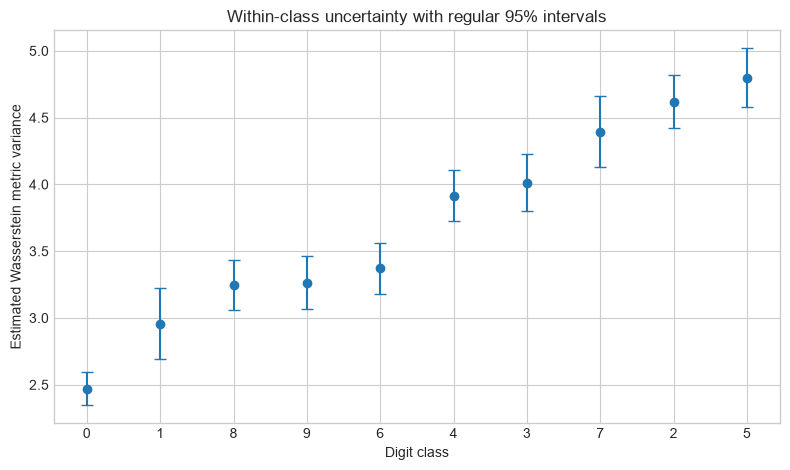

In [4]:
ordered = mnist.sort_values("estimate_VW")
asymmetric_error = np.vstack(
    [
        ordered["estimate_VW"] - ordered["lower_VW_regular"],
        ordered["upper_VW_regular"] - ordered["estimate_VW"],
    ]
)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.errorbar(
    ordered["digit"].astype(str),
    ordered["estimate_VW"],
    yerr=asymmetric_error,
    fmt="o",
    capsize=4,
    color="#1f77b4",
)
ax.set(
    xlabel="Digit class",
    ylabel="Estimated Wasserstein metric variance",
    title="Within-class uncertainty with regular 95% intervals",
)
fig.tight_layout()
plt.show()

The leading classes form a high-uncertainty group rather than a strict ranking.
Their intervals overlap, so the plot should not be read as a complete pairwise
significance analysis.

## Omnibus equality test

The classes are independent. A contrast matrix therefore combines their
regular variances into a Wald test of equal class totals.

In [5]:
estimates = mnist["estimate_VW"].to_numpy()
variances = mnist["se_VW_regular"].to_numpy() ** 2
groups = estimates.size
contrast = np.column_stack((-np.ones(groups - 1), np.eye(groups - 1)))
difference = contrast @ estimates
middle = contrast @ np.diag(variances) @ contrast.T
wald_q = float(difference @ np.linalg.solve(middle, difference))

pd.Series(
    {
        "Wald Q": wald_q,
        "degrees of freedom": groups - 1,
        "smallest Gamma1 estimate": mnist["gamma1_VW"].min(),
        "largest Gamma1 estimate": mnist["gamma1_VW"].max(),
    }
).round(4)

Wald Q                      644.7141
degrees of freedom            9.0000
smallest Gamma1 estimate      0.4885
largest Gamma1 estimate       2.3092
dtype: float64

Every estimated first-projection variance is positive and well separated from
zero. Regular complete-pair intervals are therefore appropriate for this
application.

## Optional matrix-level recomputation

The offline summary is enough to reproduce the reported complete-pair values.
Matrix-level balanced inference requires the original public distance files.

Install `requirements-online.txt`, then run the following command from the
package root:

```sh
PYTHONPATH=src python -m bmu.mnist_online --outdir mnist_recomputed
```

The download is intentionally optional. The other notebooks and every stored
paper-scale result run without network access.

In [6]:
n = 500
k_matchings = 14
selected_pairs = n * k_matchings // 2
complete_pairs = n * (n - 1) // 2
pd.Series(
    {
        "balanced pairs per class": selected_pairs,
        "complete pairs per class": complete_pairs,
        "balanced fraction": selected_pairs / complete_pairs,
    }
)

balanced pairs per class      3500.000000
complete pairs per class    124750.000000
balanced fraction                0.028056
dtype: float64